In [65]:
import jax.numpy as jnp
import numpy as np
import jax
jax.config.update("jax_enable_x64", True)

from jax_gbp import (
    lens_step, 
    propagate, 
    propagate_non_paraxial, 
    Q2_inv,
    Ray
)

%matplotlib widget

In [66]:
# Define constants
SOURCE = 0
LENS = 1
DETECTOR = 2

# Run the model
def run_model(ray, model_params):
    for component in model_params:
        component_type = model_params[component]['type']
        z = model_params[component]['z']

        distance = z - ray.z
        ray = propagate(distance, ray)

    return ray.matrix

# Model params
source_1_params = {'type': SOURCE,
                   'z': 0.0}

lens_1_params = {'type': LENS,
                 'z': 0.5, 
                 'focal_length': 0.1}

detector_1_params = {'type': DETECTOR,
                     'z': 1.0, 
                     'shape': (100, 100), 
                     'px_size': 0.01, 
                     'centre_yx': (0.0, 0.0)}

model_params = {'source_1': source_1_params,
                'lens_1': lens_1_params,
                'detector_1': detector_1_params}

n_rays = 4
n_rays_dim = int(jnp.sqrt(n_rays))

input_amplitude = 1.0
input_pathlength = 0.0
input_wavelength = 1.0

# Prepare multiple input rays (each row is a separate ray)
r1mx = jnp.linspace(-0.1, 0.1, n_rays_dim)
r1my = jnp.linspace(-0.1, 0.1, n_rays_dim)
r1m = jnp.stack(jnp.meshgrid(r1mx, r1my), axis=-1).reshape(2, -1)

theta1mx = jnp.linspace(-0.0, 0.0, n_rays_dim)
theta1my = jnp.linspace(-0.0, 0.0, n_rays_dim)
theta1m = jnp.stack(jnp.meshgrid(theta1mx, theta1my), axis=-1).reshape(2, -1)

rays_input = jnp.vstack([r1m[0, :], r1m[1, :], theta1m[0, :], theta1m[1, :], jnp.ones((n_rays))]).T

def create_ray(ray_data):
    return Ray(z=0.0, matrix=ray_data,
               amplitude=input_amplitude,
               pathlength=input_pathlength,
               wavelength=input_wavelength)

# vmap over run_model to process each ray in rays_input
batched_run_model = jax.vmap(lambda r: run_model(create_ray(r), model_params))
ray_outputs = batched_run_model(rays_input)

# # Partial derivatives of ray output with respect to ray input
batched_dro_dri = jax.vmap(lambda r: jax.jacobian(run_model, argnums=0)(create_ray(r), model_params))
dro_dri = batched_dro_dri(rays_input)

ABCD = dro_dri.matrix

# Extract ABCD matrices
A = ABCD[:, :2, :2]
B = ABCD[:, :2, 2:4]
C = ABCD[:, 2:4, :2]
D = ABCD[:, 2:4, 2:4]

In [67]:
# Define a single matrix-vector multiplication
def matvec_mul(matrix, vector):
    return jnp.dot(matrix, vector)

# Vectorize the operation across the batch dimension using vmap
batch_matvec_mul = jax.vmap(matvec_mul, in_axes=(0, 0), out_axes=0)

# Just-In-Time compile the vectorized function for performance
jit_batch_matvec_mul = jax.jit(batch_matvec_mul)

R = jit_batch_matvec_mul(ABCD, rays_input)

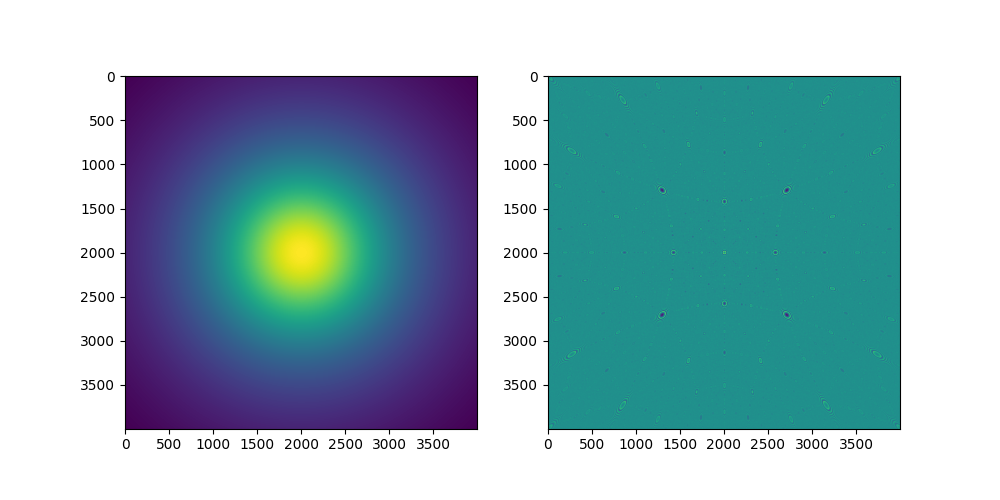

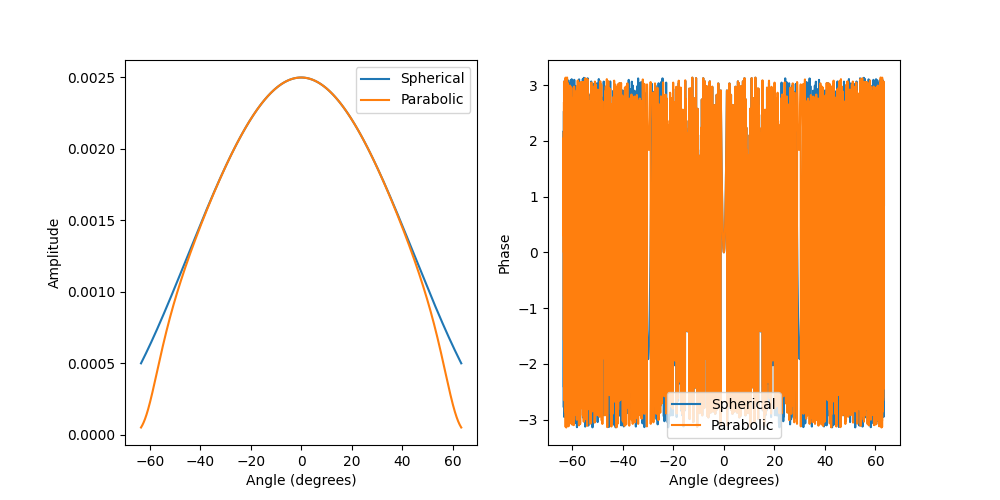

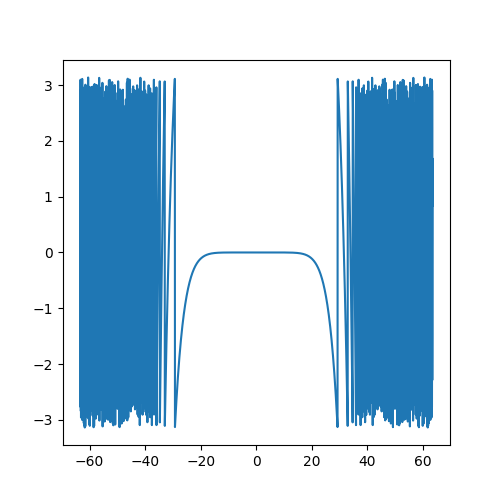

In [68]:
R = 20
input_wavelength = 0.01
k = 2 * np.pi / input_wavelength

npx = 4000
x = np.linspace(-40, 40, npx)
y = np.linspace(-40, 40, npx)
X, Y = np.meshgrid(x, y)

# Calculate the phase of a spherical point source with a radius of curvature of R = 0.5
OPL = np.sqrt(R**2 + X**2 + Y**2)
phase = np.mod(k * OPL - np.pi, 2*np.pi) - np.pi

# Calculate the Amplitude of the spherical wavefront, which has a 1/r**2 dependence
amplitude = 1 / OPL**2

rho = np.sqrt(X**2 + Y**2)
# Calculate the phase of a parabolic point source, with a radius of curvature of R = 0.5
OPL_parabolic = R + rho**2 / (2*R) - (rho**4 / (8*R**3)) + (rho**6 / (16*R**5)) - (rho**8 / (128*R**7)) + (rho**10 / (256*R**9))

phase_parabolic = np.mod(k * OPL_parabolic - np.pi, 2*np.pi) - np.pi

#Calculate the amplitude of the parabolic wavefront
amplitude_parabolic = 1 / OPL_parabolic**2


# Plot the 2D amplitude and phase of the wavefront
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(amplitude)
ax[1].imshow(phase)
plt.show()

# Plot a cross section in x of the amplitude and phase
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
theta_deg = np.degrees(np.arctan(x / R))  # Assuming z = 1.0

ax[0].plot(theta_deg, amplitude[npx//2, :], label='Spherical')
ax[0].plot(theta_deg, amplitude_parabolic[npx//2, :], label='Parabolic')
ax[0].set_xlabel('Angle (degrees)')
ax[0].set_ylabel('Amplitude')
ax[0].legend()

ax[1].plot(theta_deg, phase[npx//2, :], label='Spherical')
ax[1].plot(theta_deg, phase_parabolic[npx//2, :], label='Parabolic')
ax[1].set_xlabel('Angle (degrees)')
ax[1].set_ylabel('Phase')
ax[1].legend()

# Plot the difference in phase between the spherical and parabolic wavefronts
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
diff_phase = np.mod(k * (OPL[npx//2, :] - OPL_parabolic[npx//2, :]) - np.pi, 2*np.pi) - np.pi
ax.plot(theta_deg, diff_phase)



In [69]:
# Define constants
SOURCE = 0
DETECTOR = 1

z_det = 2.5

# Run the model
def run_model(ray, model_params):
    for component in model_params:
        component_type = model_params[component]['type']
        z = model_params[component]['z']

        if component_type == SOURCE:
            continue
        # elif component_type == DETECTOR:
        #     continue
        
        distance = z - ray.z
        ray = propagate_non_paraxial(distance, ray)


    return ray

# Model params
source_1_params = {'type': SOURCE,
                   'z': 0.0}

detector_1_params = {'type': DETECTOR,
                     'z': z_det, 
                     'shape': (10, 10), 
                     'px_size': 1, 
                     'centre_yx': (0.0, 0.0)}

model_params = {'source_1': source_1_params,
                'detector_1': detector_1_params}

n_rays = detector_1_params['shape'][0] * detector_1_params['shape'][1]
n_rays_dim = int(jnp.sqrt(n_rays))
input_amplitude = 1.0
input_pathlength = 0.0
input_wavelength = 1.0

# Prepare multiple input rays (each row is a separate ray)
r1mx = jnp.linspace(-0.0, 0.0, n_rays_dim)
r1my = jnp.linspace(-0.0, 0.0, n_rays_dim)
r1m = jnp.stack(jnp.meshgrid(r1mx, r1my), axis=-1).reshape(2, -1)

x_coords = jnp.linspace(-detector_1_params['shape'][0] * detector_1_params['px_size'] / 2,
                        detector_1_params['shape'][0] * detector_1_params['px_size'] / 2,
                        detector_1_params['shape'][0])
y_coords = jnp.linspace(-detector_1_params['shape'][1] * detector_1_params['px_size'] / 2,
                        detector_1_params['shape'][1] * detector_1_params['px_size'] / 2,
                        detector_1_params['shape'][1])

X, Y = jnp.meshgrid(x_coords, y_coords)

# Calculate the angles
angles = jnp.arctan2(Y.ravel(), X.ravel())

# Calculate the slopes
slopes_x = X.ravel() / z_det
slopes_y = Y.ravel() / z_det

# theta1mx = slopes_x
# theta1my = slopes_y
theta1m = jnp.stack((slopes_x, slopes_y))

rays_input = jnp.vstack([r1m[0, :], r1m[1, :], theta1m[0, :], theta1m[1, :], jnp.ones((n_rays))]).T

def create_ray(ray_data):
    return Ray(z=0.0, matrix=ray_data,
               amplitude=input_amplitude,
               pathlength=input_pathlength,
               wavelength=input_wavelength,
               w0x=0.01,
               Rx=0.0,
               w0y=0.01,
               Ry=0.0)

# vmap over run_model to process each ray in rays_input
batched_run_model = jax.vmap(lambda r: run_model(create_ray(r), model_params))
ray_outputs = batched_run_model(rays_input)

ray_outputs_matrix = ray_outputs.matrix
amplitude = ray_outputs.amplitude
OPL = ray_outputs.pathlength

# # Partial derivatives of ray output with respect to ray input
batched_dro_dri = jax.vmap(lambda r: jax.jacobian(run_model, argnums=0)(create_ray(r), model_params))
dro_dri = batched_dro_dri(rays_input)

ABCD = dro_dri.matrix.matrix

# Extract ABCD matrices
A = ABCD[:, :2, :2]
B = ABCD[:, :2, 2:4]
C = ABCD[:, 2:4, :2]
D = ABCD[:, 2:4, 2:4]

rays_input = jnp.vstack([r1m[0, :], r1m[1, :], theta1m[0, :], theta1m[1, :], jnp.ones((n_rays))]).T
R = jit_batch_matvec_mul(ABCD, rays_input)


In [70]:
print(B)
print(R)
print(ray_outputs_matrix)
print(OPL)

[[[ 2.50000000e+00  0.00000000e+00]
  [ 0.00000000e+00  2.50000000e+00]]

 [[ 2.50000000e+00  2.22044605e-16]
  [ 0.00000000e+00  2.50000000e+00]]

 [[ 2.50000000e+00  1.11022302e-16]
  [ 1.11022302e-16  2.50000000e+00]]

 [[ 2.50000000e+00  0.00000000e+00]
  [ 0.00000000e+00  2.50000000e+00]]

 [[ 2.50000000e+00 -2.77555756e-17]
  [ 0.00000000e+00  2.50000000e+00]]

 [[ 2.50000000e+00  5.55111512e-17]
  [ 0.00000000e+00  2.50000000e+00]]

 [[ 2.50000000e+00  1.11022302e-16]
  [ 0.00000000e+00  2.50000000e+00]]

 [[ 2.50000000e+00 -1.11022302e-16]
  [-1.11022302e-16  2.50000000e+00]]

 [[ 2.50000000e+00 -2.22044605e-16]
  [ 0.00000000e+00  2.50000000e+00]]

 [[ 2.50000000e+00  0.00000000e+00]
  [ 0.00000000e+00  2.50000000e+00]]

 [[ 2.50000000e+00  0.00000000e+00]
  [ 2.22044605e-16  2.50000000e+00]]

 [[ 2.50000000e+00  0.00000000e+00]
  [ 0.00000000e+00  2.50000000e+00]]

 [[ 2.50000000e+00  0.00000000e+00]
  [ 1.11022302e-16  2.50000000e+00]]

 [[ 2.50000000e+00  1.11022302e-16]
  

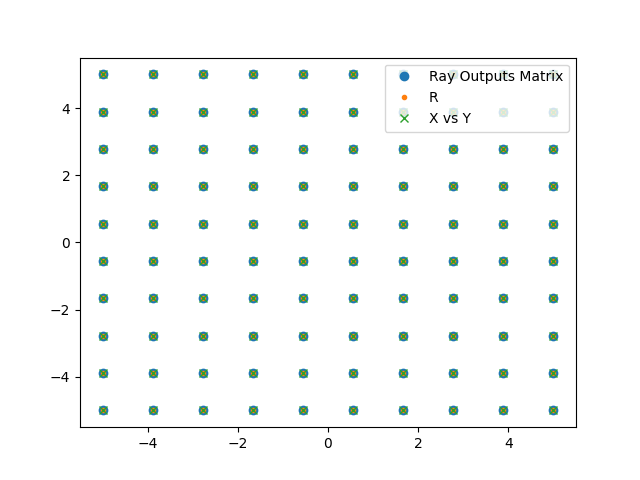

In [71]:
plt.figure()
plt.plot(ray_outputs_matrix[:, 0], ray_outputs_matrix[:, 1], 'o', label='Ray Outputs Matrix')
plt.plot(R[:, 0], R[:, 1], '.', label='R')
plt.plot(X.ravel(), Y.ravel(), 'x', label='X vs Y')
plt.legend()

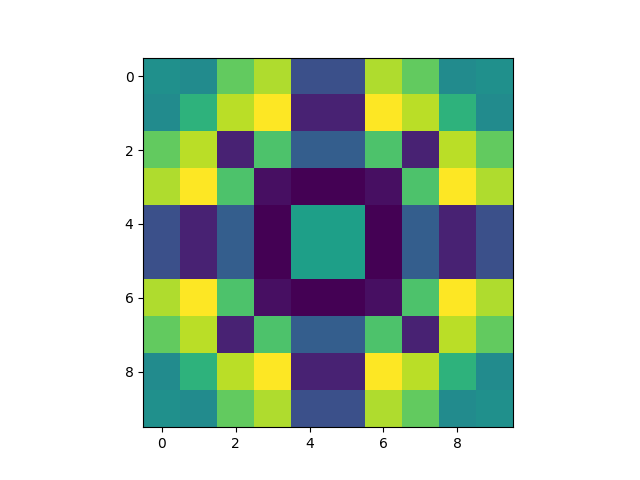

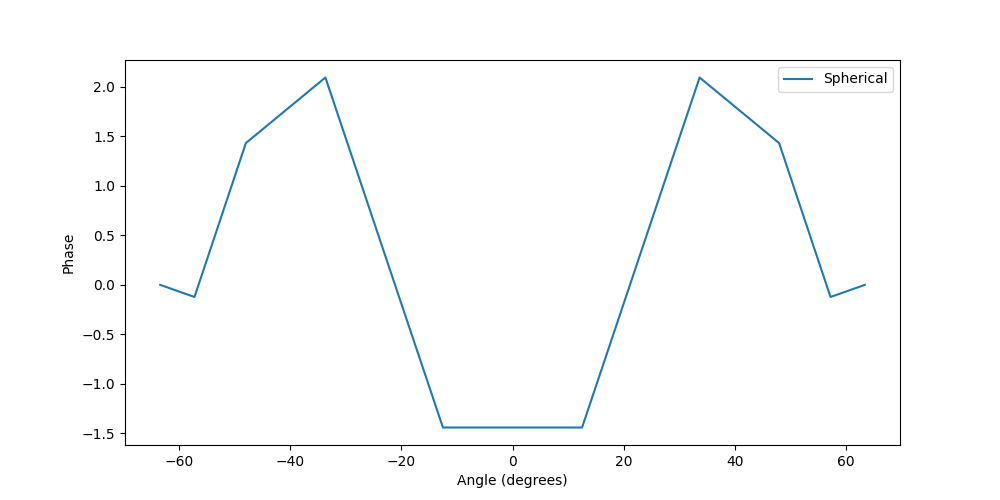

In [72]:
phase = (jnp.mod(k * OPL - jnp.pi, 2*jnp.pi) - jnp.pi).reshape(detector_1_params['shape'])

plt.figure()
plt.imshow(phase)

# Plot a cross section in x of the amplitude and phase
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
theta_deg = np.degrees(np.arctan(x_coords / z_det))  # Assuming z = 1.0

ax.plot(theta_deg, phase[npx//2, :], label='Spherical')
ax.set_xlabel('Angle (degrees)')
ax.set_ylabel('Phase')
ax.legend()

In [73]:
Q1inv = ray_outputs.qx_inv
Q1inv = jnp.zeros((n_rays, 2, 2), dtype=jnp.complex128)
Qinv = Q1inv.at[:, 0, 0].set(ray_outputs.qx_inv)
Q1inv = Q1inv.at[:, 1, 1].set(ray_outputs.qy_inv)
Q2inv = Q2_inv(Q1inv, A, B, C, D)

print(Q2inv.shape)

print(OPL)
1/Q2inv[1][1, 1].real

(100, 2, 2)
[7.5        6.80980593 6.24227918 5.83333333 5.61770789 5.61770789
 5.83333333 6.24227918 6.80980593 7.5        6.80980593 6.04126755
 5.39346884 4.91439056 4.65640406 4.65640406 4.91439056 5.39346884
 6.04126755 6.80980593 6.24227918 5.39346884 4.65640406 4.09192218
 3.77818625 3.77818625 4.09192218 4.65640406 5.39346884 6.24227918
 5.83333333 4.91439056 4.09192218 3.43592135 3.05555556 3.05555556
 3.43592135 4.09192218 4.91439056 5.83333333 5.61770789 4.65640406
 3.77818625 3.05555556 2.62055031 2.62055031 3.05555556 3.77818625
 4.65640406 5.61770789 5.61770789 4.65640406 3.77818625 3.05555556
 2.62055031 2.62055031 3.05555556 3.77818625 4.65640406 5.61770789
 5.83333333 4.91439056 4.09192218 3.43592135 3.05555556 3.05555556
 3.43592135 4.09192218 4.91439056 5.83333333 6.24227918 5.39346884
 4.65640406 4.09192218 3.77818625 3.77818625 4.09192218 4.65640406
 5.39346884 6.24227918 6.80980593 6.04126755 5.39346884 4.91439056
 4.65640406 4.65640406 4.91439056 5.39346884 6.041

Array(2.54052847, dtype=float64)